In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import random

In [2]:
train_data=pd.read_csv("fashion-mnist_train.csv")
test_data=pd.read_csv("fashion-mnist_test.csv")

In [3]:
train_img=train_data.iloc[:,1:]
train_labels=train_data.iloc[:,0]
test_img=test_data.iloc[:,1:]
test_labels=test_data.iloc[:,0]

In [4]:
train_img=np.array(train_img)
test_img=np.array(test_img)
train_labels=np.array(train_labels)
test_labels=np.array(test_labels)


In [5]:
train_img=train_img.reshape(-1,28,28)
test_img=test_img.reshape(-1,28,28)

In [6]:
train_img=train_img/255.0
test_img=test_img/255.0

In [7]:
train_img=train_img.reshape((60000,28,28,1))
test_img=test_img.reshape((10000,28,28,1))

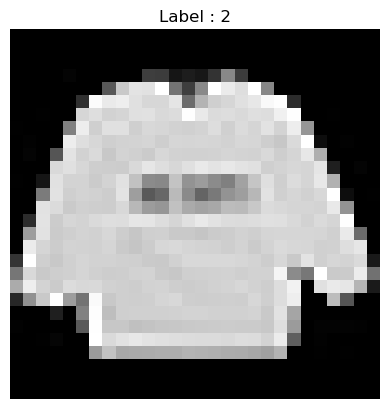

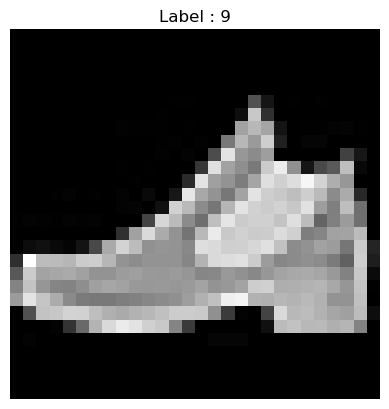

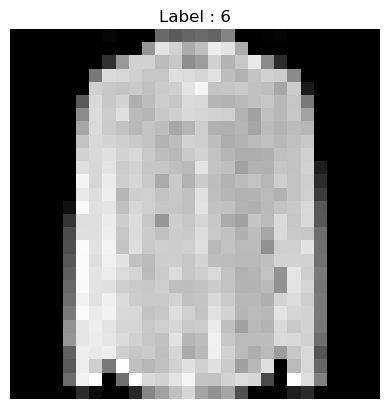

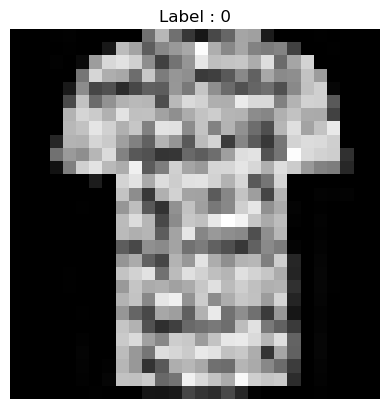

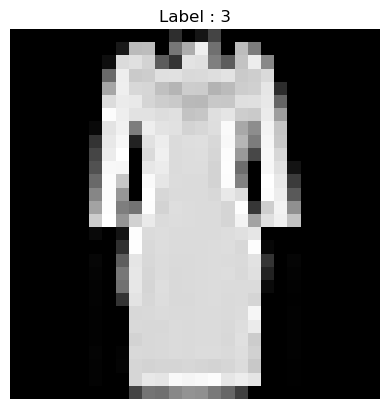

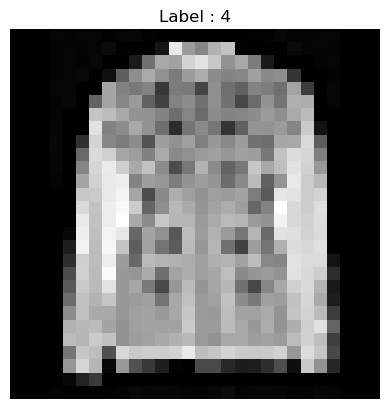

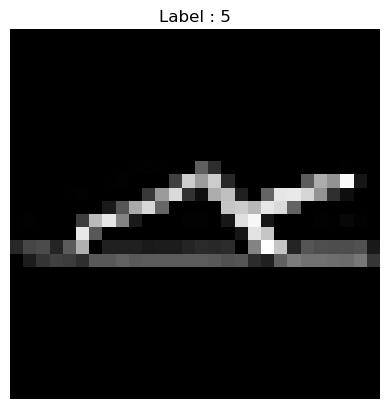

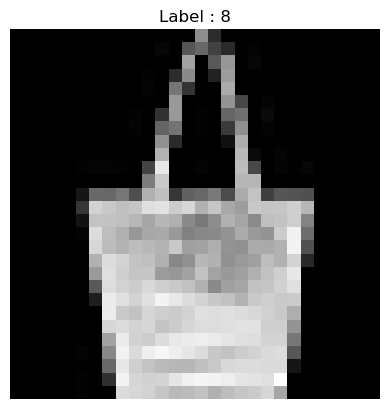

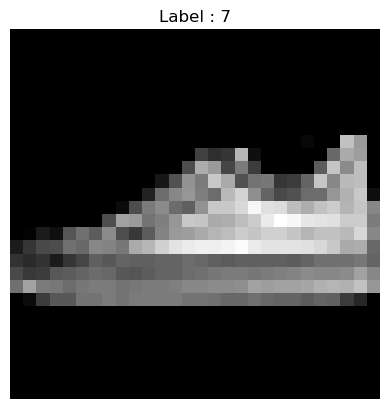

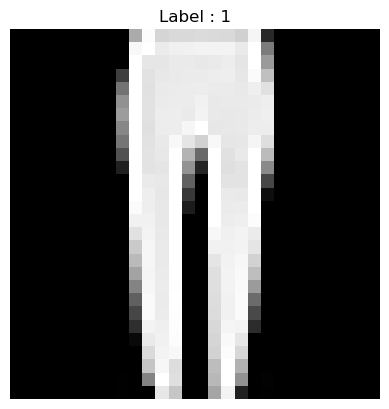

In [8]:
shown=set()
for i in range(len(train_img)):
    labels=train_labels[i]
    if labels not in shown:
        plt.imshow(train_img[i].reshape(28,28),cmap='gray')
        plt.title(f"Label : {labels}")
        plt.axis('off')
        plt.show()
        shown.add(labels)
    if len(shown)==10:
        break;

In [9]:
class_names=['Tshirt','Pant','Sweatshirt','Dress','Jacket','Sandal','Shirt','Shoes','Bag','Boot']

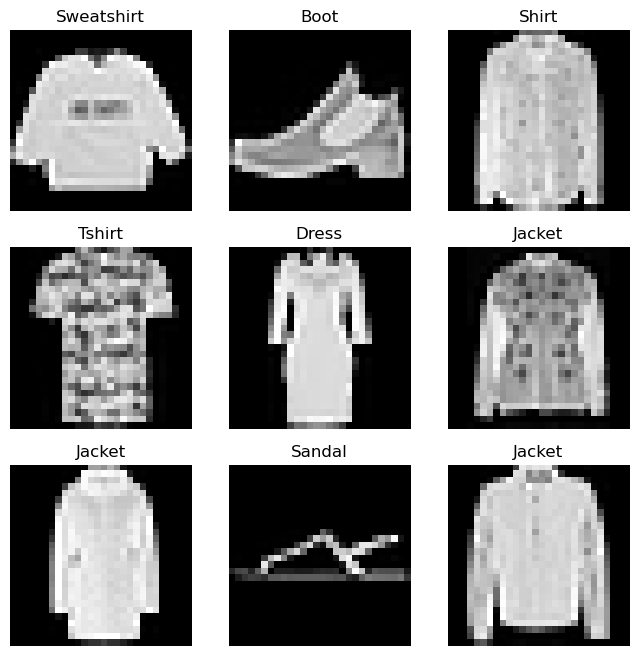

In [10]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_img[i].reshape(28,28),cmap='gray')
    true_label=train_labels[i]
    plt.title(class_names[true_label])
    plt.axis('off')
plt.show()

In [11]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])              

C:\Users\amanp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=2
)

In [14]:
history=model.fit(
    train_img,train_labels,
    epochs=5,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.7519 - loss: 0.6788 - val_accuracy: 0.8490 - val_loss: 0.4180
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8279 - loss: 0.4741 - val_accuracy: 0.8730 - val_loss: 0.3543
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8491 - loss: 0.4188 - val_accuracy: 0.8790 - val_loss: 0.3322
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8619 - loss: 0.3820 - val_accuracy: 0.8927 - val_loss: 0.2903
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8727 - loss: 0.3509 - val_accuracy: 0.9010 - val_loss: 0.2845


In [16]:
loss,accuracy=model.evaluate(test_img,test_labels)
print("Accuracy :")
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9004 - loss: 0.2759
Accuracy :
0.9003999829292297


In [17]:
predictions=model.predict(test_img)
y_pred=np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


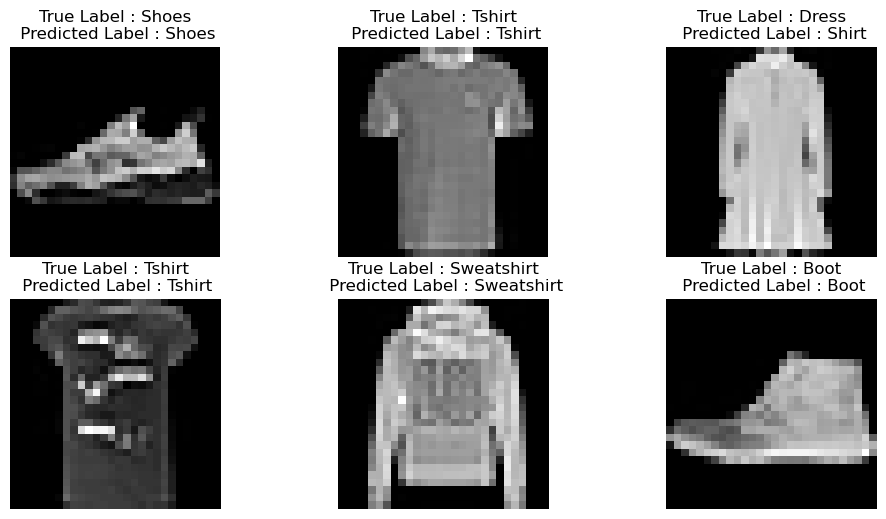

In [18]:
plt.figure(figsize=(12,6))
for i in range(6):
    index=random.randint(0,len(test_img)-1)
    plt.subplot(2,3,i+1)
    plt.imshow(test_img[index].reshape(28,28),cmap='gray')
    pred_label=class_names[y_pred[index]]
    true_label=class_names[test_labels[index]]
    plt.title(f"True Label : {true_label}\n Predicted Label : {pred_label}")
    plt.axis('off')
plt.show()

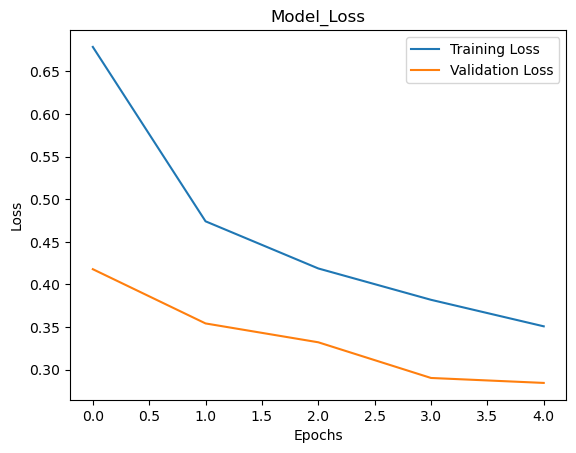

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model_Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Validation Loss'])
plt.show()